<a href="https://colab.research.google.com/github/amalbijukurian/wine-prediction-using-Deep-Learning/blob/main/wine_prediction_using_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving wine_quality.csv to wine_quality (3).csv


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input

from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("wine_quality.csv")
df.head()


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
df['type'] = df['type'].map({
    'white': 0,
    'red': 1
})
df = df.fillna(df.mean())
print(df.isnull().sum())

df['quality'] = (df['quality'] >= 7).astype(int)

X = df.drop('quality', axis=1)
y = df['quality']

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7763 - loss: 0.4824 - val_accuracy: 0.8163 - val_loss: 0.4152
Epoch 2/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8304 - loss: 0.3862 - val_accuracy: 0.8192 - val_loss: 0.3900
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8328 - loss: 0.3698 - val_accuracy: 0.8250 - val_loss: 0.3843
Epoch 4/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8321 - loss: 0.3624 - val_accuracy: 0.8231 - val_loss: 0.3848
Epoch 5/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8333 - loss: 0.3588 - val_accuracy: 0.8269 - val_loss: 0.3731
Epoch 6/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8350 - loss: 0.3500 - val_accuracy: 0.8269 - val_loss: 0.3777
Epoch 7/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8388 - loss: 0.3461 - val_accuracy: 0.8317 - val_loss: 0.3710
Epoch 8/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8379 - loss: 0.3417 - val_accuracy: 0

In [7]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy*100)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8323 - loss: 0.3520
Test Accuracy: 83.23076963424683


In [8]:
#Actual vs predicted
predictions = model.predict(X_test)
predictions = (predictions > 0.5).astype(int)
print("Predictions:")
print(predictions[:10].flatten())

print("Actual:")
print(y_test[:10].values)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Predictions:
[0 0 0 0 0 1 0 0 0 0]
Actual:
[1 1 0 0 0 1 0 0 0 0]


In [9]:
#new wine prediction
sample = [[
    0,      # type
    7.4,    # fixed acidity
    0.70,   # volatile acidity
    0.00,   # citric acid
    1.9,    # residual sugar
    0.076,  # chlorides
    11.0,   # free sulfur dioxide
    34.0,   # total sulfur dioxide
    0.9978, # density
    3.51,   # pH
    0.56,   # sulphates
    9.4     # alcohol
]]
sample = scaler.transform(sample)
prediction = model.predict(sample)
print(prediction)

if prediction > 0.5:
    print("Good Wine")
else:
    print("Bad Wine")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
[[0.00080545]]
Bad Wine


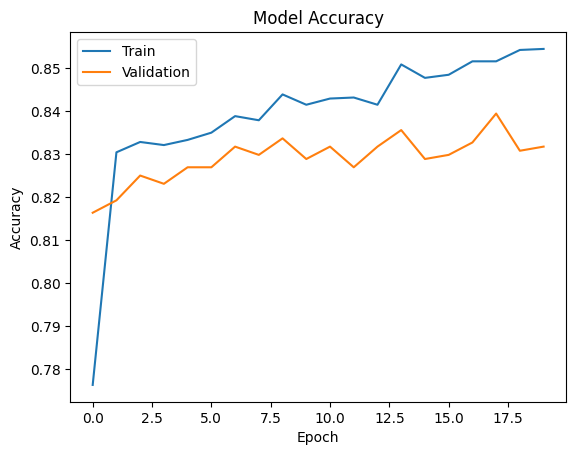

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

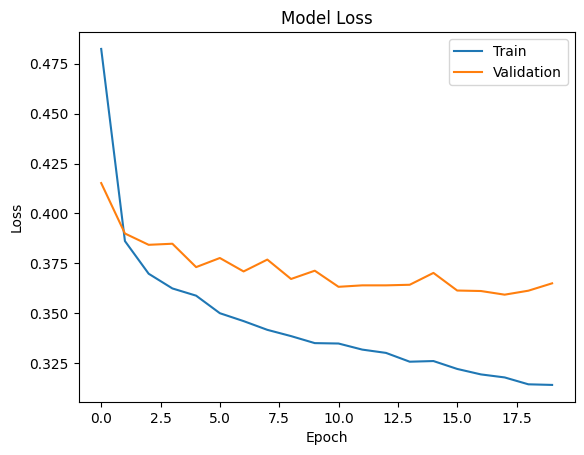

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

In [13]:
model.save("wine_model.keras")
from google.colab import files

files.download("wine_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>